# 📊 RAG Pipeline for Annual Report Q&A

**Author:** Sanusi Isiaka Olatunji  
**Stack:** `google-genai` · `ChromaDB` · `LangChain` · `UMAP` · `Gradio`

End-to-end Retrieval-Augmented Generation pipeline applied to a corporate annual report PDF, with LLM-based evaluation, embedding drift monitoring, and an interactive Gradio dashboard.

### Full pipeline
```
PDF → Extract → Chunk → Embed → ChromaDB
    → HyDE / Multi-query retrieval
    → Generate answer (Gemini)
    → Evaluate (faithfulness · relevance · completeness)
    → Drift monitor (cosine similarity over time)
    → Gradio dashboard
```

| Technique | Description |
|---|---|
| **Two-stage chunking** | Character split → token split |
| **HyDE** | Hypothetical Document Embeddings for better query-answer alignment |
| **Multi-query expansion** | 5 sub-questions to widen recall |
| **LLM-as-judge evaluation** | Gemini scores each answer on faithfulness, relevance and completeness |
| **Embedding drift monitoring** | Tracks cosine similarity between queries and corpus centroid over time |
| **Gradio UI** | Interactive Q&A + live evaluation + drift chart |

## 1 · Install dependencies

In [2]:
!pip install chromadb pypdf google-genai langchain-text-splitters \
             sentence-transformers umap-learn gradio --quiet

## 2 · Imports

In [3]:
import os
import json
import datetime
import numpy as np
import matplotlib
matplotlib.use('Agg')   # non-interactive backend — safe for Gradio inside Colab
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import fill as word_wrap
from collections import deque

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from pypdf import PdfReader
import umap
import gradio as gr

from google import genai
from google.genai import types
from google.colab import userdata

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    SentenceTransformersTokenTextSplitter,
)

print('✅ All imports successful')

✅ All imports successful


## 3 · Configure Gemini client

> Store your key in **Colab Secrets** (🔑 left sidebar) under `Gemini_API_Key`.

In [10]:
client      = genai.Client(api_key=userdata.get('Gemini_API_Key'))
GEMINI_MODEL = 'models/gemini-2.5-flash'
print('✅ Gemini client ready')

✅ Gemini client ready


## 4 · Load and extract PDF text

Upload your PDF via the Colab file browser (📁 left sidebar) and update `PDF_PATH`.

In [11]:
PDF_PATH  = '/content/2023_Annual_Report.pdf'   # ← update if needed

reader    = PdfReader(PDF_PATH)
pdf_texts = [p.extract_text().strip() for p in reader.pages]
pdf_texts = [t for t in pdf_texts if t]

print(f'Pages extracted : {len(pdf_texts)}')
print(f'Total characters: {sum(len(t) for t in pdf_texts):,}\n')
print(word_wrap(pdf_texts[0], width=100))

Pages extracted : 83
Total characters: 286,488

1  Dear shareholders, colleagues, customers, and partners,   We are living through a time of
historic challenge and opportunity. As I write this, the world faces ongoing economic, social,  and
geopolitical volatility. At the same time, we have entered a new age of AI that will fundamentally
transform productivity   for every individual, organization, and industry on earth, and help us
address some of our most pressing challenges.   This next generation of AI will reshape every
software category and every business, including our own. Forty -eight years  after its founding,
Microsoft remains a consequential company because time and time again —from PC/Server, to
Web/Internet, to Cloud/Mobile—we have adapted to technological paradigm shifts. Today, we are doing
so once again, as  we lead this new era.   Amid this transformation, our mission to empower every
person and every organization on the planet to achieve  more remains constant. As a c

## 5 · Two-stage chunking

**Stage 1** — `RecursiveCharacterTextSplitter`: splits on `\n\n`, `\n`, `.` etc. up to 1 000 chars.  
**Stage 2** — `SentenceTransformersTokenTextSplitter`: re-splits to fit within the 256-token window of `all-MiniLM-L6-v2`.

In [12]:
character_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100,
    separators=['\n\n', '\n', '.', '!', '?', ',', ' ', ''],
)
character_split_texts = character_splitter.split_text('\n\n'.join(pdf_texts))
print(f'Stage 1 — character chunks : {len(character_split_texts)}')

token_splitter    = SentenceTransformersTokenTextSplitter(chunk_overlap=0, tokens_per_chunk=256)
token_split_texts = []
for text in character_split_texts:
    token_split_texts += token_splitter.split_text(text)

print(f'Stage 2 — token chunks     : {len(token_split_texts)}')
print(f'\nSample chunk (index 10):\n')
print(word_wrap(token_split_texts[10], width=100))

Stage 1 — character chunks : 347


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Stage 2 — token chunks     : 353

Sample chunk (index 10):

3 all up, dynamics surpassed $ 5 billion in revenue over the past fiscal year, with our customer
experience, service, and finance and supply chain businesses each surpassing $ 1 billion in annual
sales. industry across industries, we are rapidly becoming the partner of choice for any
organization looking to generate real value from ai. in healthcare, for example, we introduced the
world ’ s first fully automated clinical documentation application, dax copilot. the application
helps physicians reduce documentation time by half, freeing them to spend more time face to face
with patients. and epic will integrate it directly into its electronic health records system. and,
in retail, we introduced new tools to help companies manage their day - to - day operations and
digitize their physical stores. modern work we are rapidly evolving microsoft 365 into an ai - first
platform that enables every individual to amplify their creativity

## 6 · Build ChromaDB collection

In [13]:
embedding_function = SentenceTransformerEmbeddingFunction(model_name='all-MiniLM-L6-v2')

chroma_client = chromadb.Client()
try:
    chroma_client.delete_collection('annual_report')
    print('Deleted existing collection')
except Exception:
    pass

chroma_collection = chroma_client.create_collection(
    name='annual_report',
    embedding_function=embedding_function,
    metadata={'hnsw:space': 'cosine'},
)

ids       = [str(i) for i in range(len(token_split_texts))]
metadatas = [{'source': str(i)} for i in range(len(token_split_texts))]
chroma_collection.add(ids=ids, metadatas=metadatas, documents=token_split_texts)
print(f'✅ {chroma_collection.count()} chunks stored in ChromaDB')

Deleted existing collection
✅ 353 chunks stored in ChromaDB


## 7 · Core RAG functions

In [14]:
def retrieve(query: str, k: int = 5) -> list[str]:
    """Embed the query and return k most similar chunk texts."""
    results = chroma_collection.query(query_texts=[query], n_results=k)
    return results['documents'][0]


def augment_query_hyde(query: str) -> str:
    """HyDE: append a hypothetical answer to the query before retrieval."""
    prompt = ('You are a financial research assistant. '
              'Write a 2-sentence example answer to the question as it would '
              'appear in a company annual report.')
    response = client.models.generate_content(
        model=GEMINI_MODEL,
        config=types.GenerateContentConfig(system_instruction=prompt),
        contents=query,
    )
    return f'{query} {response.text}'


def generate_sub_queries(query: str) -> list[str]:
    """Expand one query into up to 5 related sub-questions."""
    prompt = ('You are a financial research assistant. '
              'Propose up to five related sub-questions for the given query. '
              'One per line, no numbering.')
    response = client.models.generate_content(
        model=GEMINI_MODEL,
        config=types.GenerateContentConfig(system_instruction=prompt),
        contents=query,
    )
    return [q.strip() for q in response.text.split('\n') if q.strip()]


def generate_answer(query: str, chunks: list[str]) -> str:
    """Generate a grounded answer from retrieved chunks."""
    context = '\n\n'.join(chunks)
    system_prompt = (
        'You are a helpful expert financial research assistant. '
        'Answer using ONLY the context below. '
        'If the answer is absent say: I could not find this in the document. '
        'Be concise (3-5 sentences) and cite specific figures where available.'
    )
    response = client.models.generate_content(
        model=GEMINI_MODEL,
        config=types.GenerateContentConfig(system_instruction=system_prompt),
        contents=f'Context:\n{context}\n\nQuestion: {query}',
    )
    return response.text


print('✅ Core RAG functions defined')

✅ Core RAG functions defined


## 8 · HyDE retrieval demo

In [15]:
demo_query  = 'What was the total profit for the year and how does it compare to the previous year?'
joint_query = augment_query_hyde(demo_query)
chunks_hyde = retrieve(joint_query, k=5)
answer_hyde = generate_answer(demo_query, chunks_hyde)

print(f'Q: {demo_query}\n')
print(f'A: {word_wrap(answer_hyde, width=100)}')

Q: What was the total profit for the year and how does it compare to the previous year?

A: I could not find this in the document. The context provides information about net realized and
unrealized gains on investments, impairments, and the impact of an accounting estimate change on
operating and net income, but does not state the absolute total profit (e.g., net income) for the
year 2023 or how it compares to the previous year. It only states that operating income increased by
$4.5 billion or 15%.


## 9 · UMAP setup (fit once, reuse everywhere)

In [16]:
def project_embeddings(embeddings, umap_transform):
    return umap_transform.transform(np.array(embeddings))

all_embeddings = chroma_collection.get(include=['embeddings'])['embeddings']
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(all_embeddings)
projected_corpus = project_embeddings(all_embeddings, umap_transform)
print(f'✅ UMAP fitted on {len(all_embeddings)} embeddings')

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP fitted on 353 embeddings


## 10 · Multi-query expansion + UMAP visualisation

In [19]:
mq_query     = 'What details can you provide about the factors that led to revenue growth?'
sub_queries  = generate_sub_queries(mq_query)
all_queries  = [mq_query] + sub_queries

results_multi = chroma_collection.query(
    query_texts=all_queries, n_results=5, include=['documents', 'embeddings']
)

unique_documents = {doc for doc_list in results_multi['documents'] for doc in doc_list}
print(f'Unique chunks across all sub-queries: {len(unique_documents)}')

all_query_vecs     = embedding_function(all_queries)
all_retrieved_vecs = [v for sub in results_multi['embeddings'] for v in sub]
proj_queries       = project_embeddings(all_query_vecs,     umap_transform)
proj_retrieved_mq  = project_embeddings(all_retrieved_vecs, umap_transform)

Unique chunks across all sub-queries: 18


In [21]:
print("projected_corpus shape :", projected_corpus.shape)
print("proj_retrieved_mq shape:", proj_retrieved_mq.shape)
print("proj_queries shape     :", proj_queries.shape)

projected_corpus shape : (353, 2)
proj_retrieved_mq shape: (30, 2)
proj_queries shape     : (6, 2)


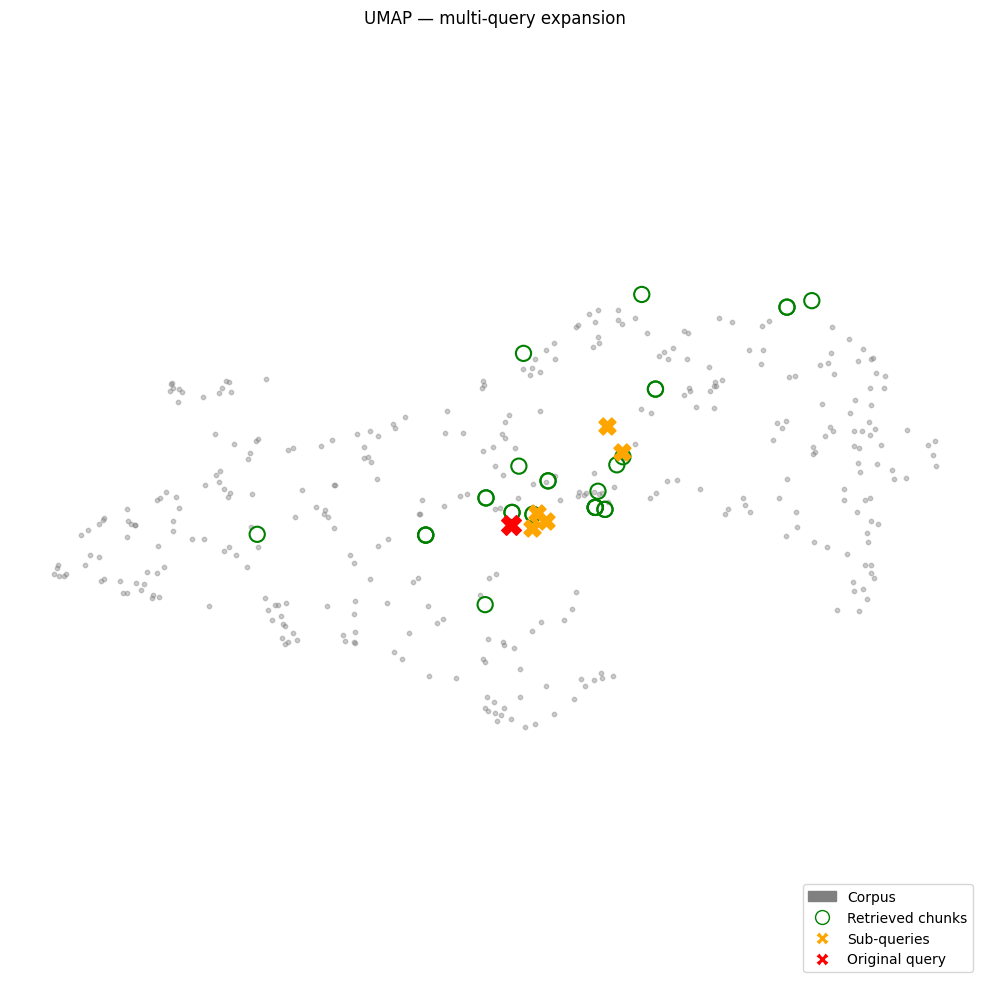

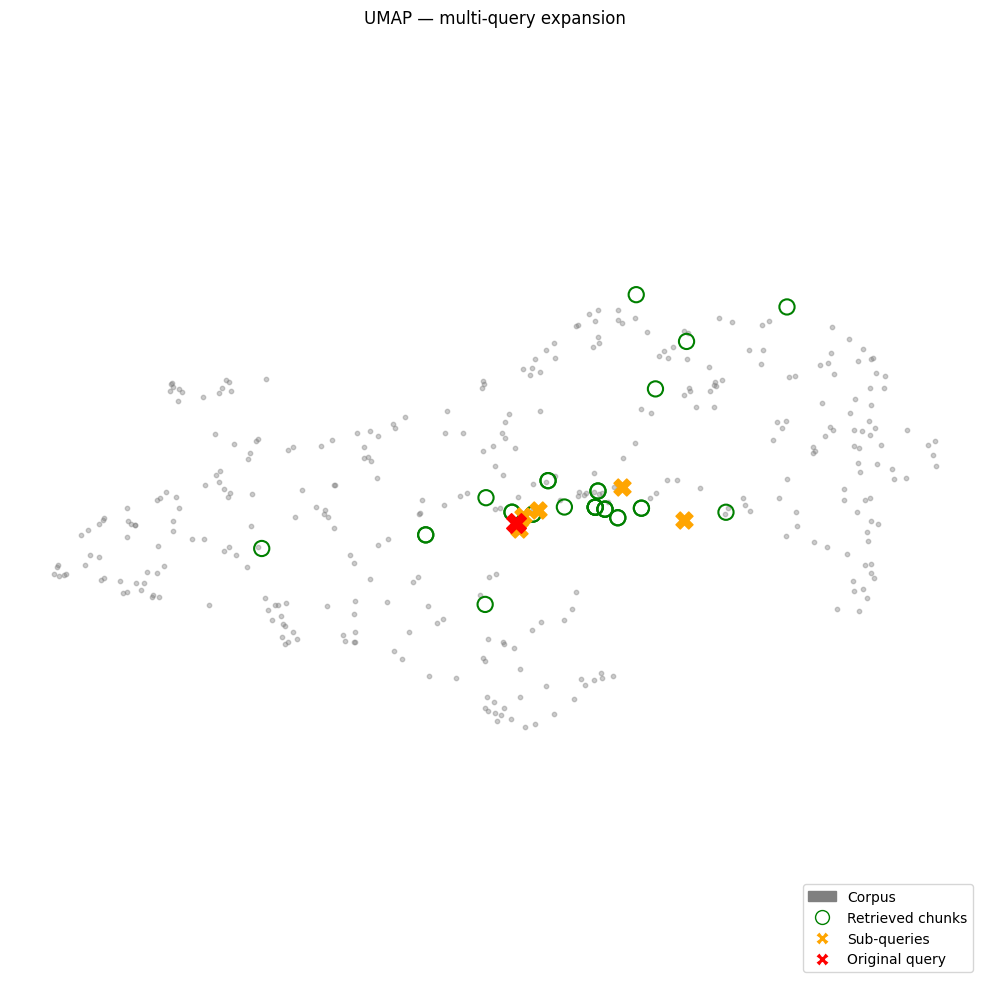

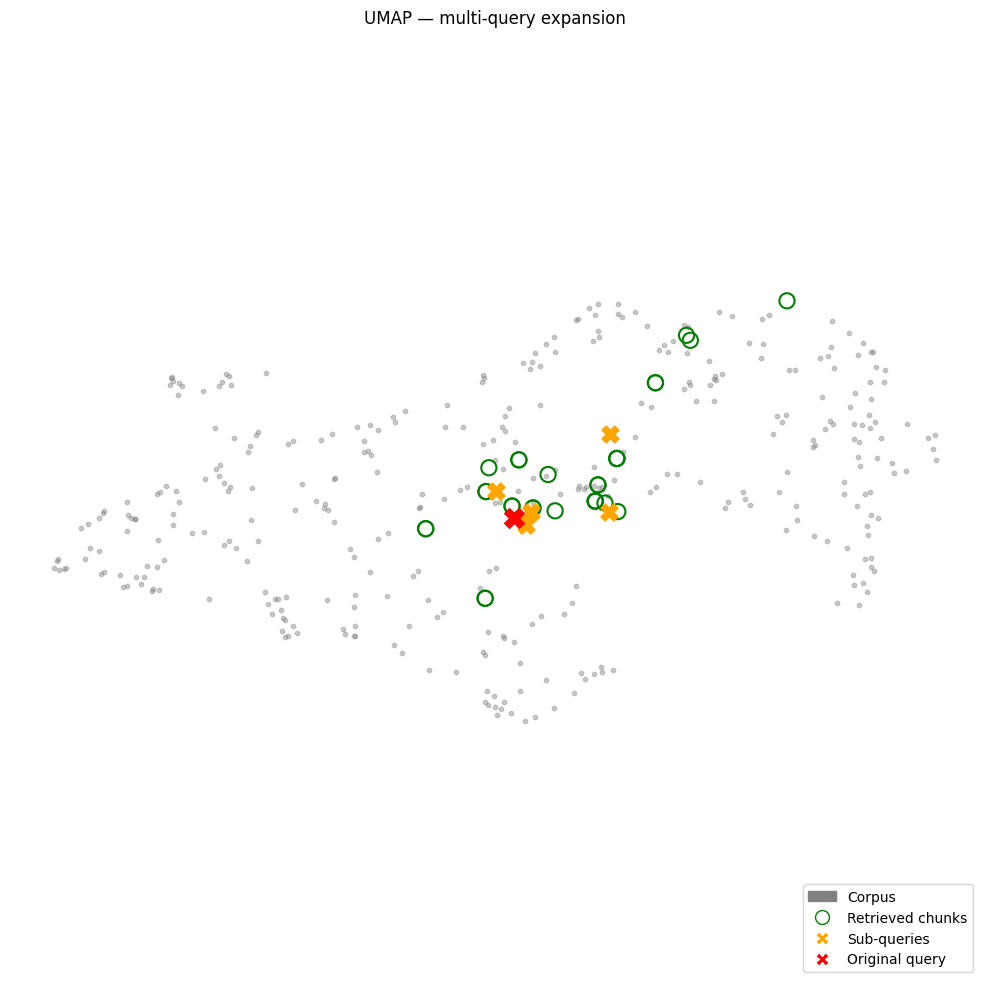

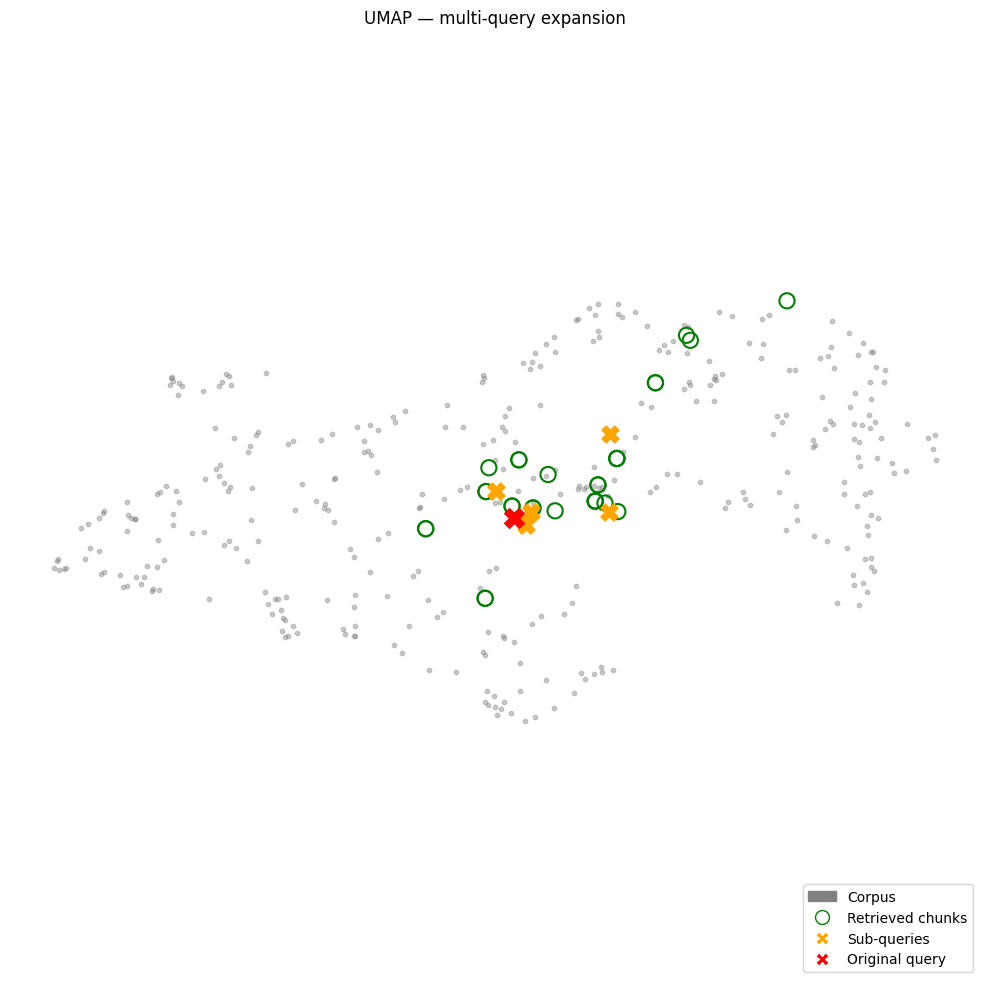

In [22]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # restore Colab display
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(projected_corpus[:, 0],    projected_corpus[:, 1],    s=10,  color='gray',  alpha=0.4)
ax.scatter(proj_retrieved_mq[:, 0],   proj_retrieved_mq[:, 1],   s=120, facecolors='none', edgecolors='green', linewidths=1.5)
ax.scatter(proj_queries[1:, 0],       proj_queries[1:, 1],       s=150, marker='X', color='orange')
ax.scatter(proj_queries[0, 0],        proj_queries[0, 1],        s=200, marker='X', color='red')
legend_elements = [
    mpatches.Patch(color='gray', label='Corpus'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='green', markersize=10, label='Retrieved chunks'),
    plt.Line2D([0],[0], marker='X', color='w', markerfacecolor='orange', markersize=10, label='Sub-queries'),
    plt.Line2D([0],[0], marker='X', color='w', markerfacecolor='red',    markersize=10, label='Original query'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8)
ax.set_aspect('equal', 'datalim')
ax.set_title(f'UMAP — multi-query expansion', fontsize=12, pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 11 · LLM-as-judge Evaluation

After generating an answer, we ask Gemini to score it on three axes:

| Metric | What it measures |
|---|---|
| **Faithfulness** | Is every claim in the answer supported by the retrieved context? |
| **Relevance** | Does the answer actually address the question asked? |
| **Completeness** | Does it cover all important aspects present in the context? |

Each score is 0–10. The evaluator returns JSON so scores can be logged and charted.

In [23]:
def evaluate_answer(question: str, context_chunks: list[str], answer: str) -> dict:
    """
    Use Gemini as an LLM judge to score the RAG answer.

    Returns
    -------
    dict with keys: faithfulness, relevance, completeness, overall, reasoning
    """
    context = '\n\n'.join(context_chunks)

    eval_prompt = """You are an expert RAG evaluation judge.
Given a QUESTION, the RETRIEVED CONTEXT, and the GENERATED ANSWER,
score the answer on three criteria (each 0-10):

- faithfulness  : every claim in the answer is supported by the context (0=hallucinated, 10=fully grounded)
- relevance     : the answer directly addresses the question (0=off-topic, 10=perfectly on-topic)
- completeness  : the answer covers all important aspects in the context (0=missing key facts, 10=comprehensive)

Respond ONLY with valid JSON, no markdown, no preamble. Example:
{"faithfulness": 8, "relevance": 9, "completeness": 7, "overall": 8.0, "reasoning": "one sentence"}"""

    user_content = (
        f'QUESTION:\n{question}\n\n'
        f'RETRIEVED CONTEXT:\n{context}\n\n'
        f'GENERATED ANSWER:\n{answer}'
    )

    response = client.models.generate_content(
        model=GEMINI_MODEL,
        config=types.GenerateContentConfig(system_instruction=eval_prompt),
        contents=user_content,
    )

    raw = response.text.strip().strip('```json').strip('```').strip()
    try:
        scores = json.loads(raw)
    except json.JSONDecodeError:
        scores = {'faithfulness': 0, 'relevance': 0, 'completeness': 0,
                  'overall': 0.0, 'reasoning': f'Parse error: {raw[:100]}'}
    return scores


print('✅ evaluate_answer() defined')

✅ evaluate_answer() defined


### Test the evaluator

In [24]:
test_q      = 'What was the total profit for the year?'
test_chunks = retrieve(augment_query_hyde(test_q), k=5)
test_answer = generate_answer(test_q, test_chunks)
scores      = evaluate_answer(test_q, test_chunks, test_answer)

print(f'Question  : {test_q}')
print(f'Answer    : {word_wrap(test_answer, width=100)}\n')
print('── Evaluation scores ──────────────────────────')
print(f'  Faithfulness : {scores.get("faithfulness", "N/A")} / 10')
print(f'  Relevance    : {scores.get("relevance",    "N/A")} / 10')
print(f'  Completeness : {scores.get("completeness", "N/A")} / 10')
print(f'  Overall      : {scores.get("overall",      "N/A")} / 10')
print(f'  Reasoning    : {scores.get("reasoning",    "N/A")}')

Question  : What was the total profit for the year?
Answer    : The total profit, or net income, for the year ended June 30, 2023, was $72,361 million. For the
prior years, net income was $72,738 million in 2022 and $61,271 million in 2021.

── Evaluation scores ──────────────────────────
  Faithfulness : 10 / 10
  Relevance    : 10 / 10
  Completeness : 10 / 10
  Overall      : 10.0 / 10
  Reasoning    : The answer accurately identifies net income as total profit and provides the exact figure for 2023, along with figures for prior years mentioned in the context, making it fully faithful, relevant, and complete.


## 12 · Embedding Drift Monitoring

**What is drift?** As users ask questions over time, the topics they ask about may shift  
away from the original document corpus. We detect this by comparing each query's embedding  
against the **corpus centroid** (the mean of all stored chunk embeddings).

- **High cosine similarity → low drift** — the query is close to the document space  
- **Low cosine similarity → high drift** — the query is asking about topics not well covered

A **rolling window** (last 20 queries) is charted live to show trends.

  sim=0.521  What was the total revenue?
  sim=0.499  How did operating expenses change?
  sim=0.467  What is the capital expenditure plan?
  sim=0.076  Tell me about football results
  sim=0.411  What are the dividend payments?


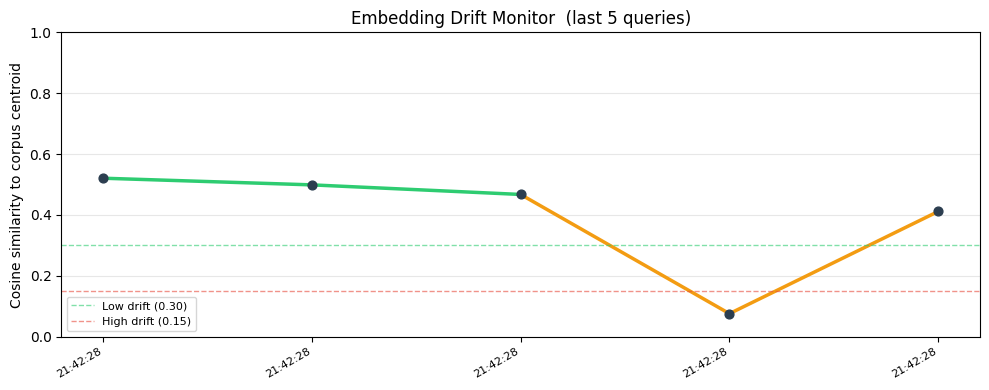

✅ Drift monitor initialised


In [25]:
# Pre-compute corpus centroid once
corpus_embeddings = np.array(chroma_collection.get(include=['embeddings'])['embeddings'])
corpus_centroid   = corpus_embeddings.mean(axis=0)   # shape: (384,)

# Rolling drift log — stores the last 50 entries
DRIFT_WINDOW = 50
drift_log: deque = deque(maxlen=DRIFT_WINDOW)         # each entry: {'query', 'similarity', 'timestamp'}


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two 1-D vectors."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))


def compute_drift(query: str) -> float:
    """
    Embed the query, compare to corpus centroid, log the result.
    Returns cosine similarity (0-1, higher = less drift).
    """
    query_vec  = np.array(embedding_function([query])[0])
    similarity = cosine_similarity(query_vec, corpus_centroid)
    drift_log.append({
        'query'     : query[:60] + ('...' if len(query) > 60 else ''),
        'similarity': round(similarity, 4),
        'timestamp' : datetime.datetime.now().strftime('%H:%M:%S'),
    })
    return similarity


def plot_drift(log: list[dict]) -> plt.Figure:
    """
    Draw a line chart of cosine similarity over the last N queries.
    Colours the line green (sim > 0.3), amber (0.15-0.3), red (< 0.15).
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    if not log:
        ax.text(0.5, 0.5, 'No queries yet', ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='gray')
        ax.set_title('Embedding Drift Monitor')
        return fig

    sims   = [e['similarity'] for e in log]
    labels = [e['timestamp']  for e in log]
    xs     = list(range(len(sims)))

    # Colour segments by threshold
    for i in range(len(sims) - 1):
        avg = (sims[i] + sims[i+1]) / 2
        color = '#2ecc71' if avg > 0.30 else ('#f39c12' if avg > 0.15 else '#e74c3c')
        ax.plot([xs[i], xs[i+1]], [sims[i], sims[i+1]], color=color, linewidth=2.5)

    ax.scatter(xs, sims, color='#2c3e50', s=40, zorder=5)
    ax.axhline(0.30, linestyle='--', color='#2ecc71', linewidth=1, alpha=0.6, label='Low drift (0.30)')
    ax.axhline(0.15, linestyle='--', color='#e74c3c', linewidth=1, alpha=0.6, label='High drift (0.15)')
    ax.set_ylim(0, 1)
    ax.set_xticks(xs[::max(1, len(xs)//10)])
    ax.set_xticklabels(labels[::max(1, len(xs)//10)], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Cosine similarity to corpus centroid')
    ax.set_title(f'Embedding Drift Monitor  (last {len(sims)} queries)')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig


# Seed the log with a few sample queries to pre-populate the chart
sample_queries = [
    'What was the total revenue?',
    'How did operating expenses change?',
    'What is the capital expenditure plan?',
    'Tell me about football results',      # ← off-topic, expect low similarity
    'What are the dividend payments?',
]
for sq in sample_queries:
    sim = compute_drift(sq)
    print(f'  sim={sim:.3f}  {sq}')

plot_drift(list(drift_log))
plt.show()
print('✅ Drift monitor initialised')

## 13 · Gradio Dashboard

Launches an interactive app with three tabs:

| Tab | What it does |
|---|---|
| **Q&A** | Ask a question → get a grounded answer via HyDE retrieval + Gemini generation |
| **Evaluation** | Scores the latest answer on faithfulness, relevance and completeness |
| **Drift Monitor** | Live chart showing how on-topic recent queries are vs the corpus |

In [26]:
# ── State shared across tabs ──────────────────────────────────
_last_state: dict = {'question': '', 'chunks': [], 'answer': ''}


# ── Tab 1: Q&A ────────────────────────────────────────────────
def gradio_ask(question: str, use_hyde: bool, k: int) -> tuple[str, str]:
    """
    Retrieve + generate. Returns (answer_text, retrieved_context_text).
    Also logs drift for this query.
    """
    if not question.strip():
        return 'Please enter a question.', ''

    retrieval_query = augment_query_hyde(question) if use_hyde else question
    chunks  = retrieve(retrieval_query, k=k)
    answer  = generate_answer(question, chunks)

    # Persist for evaluation tab
    _last_state.update({'question': question, 'chunks': chunks, 'answer': answer})

    # Log drift
    compute_drift(question)

    context_display = '\n\n---\n\n'.join(
        f'**Chunk {i+1}:**\n{c}' for i, c in enumerate(chunks)
    )
    return answer, context_display


# ── Tab 2: Evaluation ─────────────────────────────────────────
def gradio_evaluate() -> tuple[str, plt.Figure]:
    """
    Score the most recent answer and return a bar chart + text summary.
    """
    if not _last_state['answer']:
        empty_fig = plt.figure()
        plt.text(0.5, 0.5, 'Ask a question first', ha='center', va='center',
                 fontsize=14, color='gray')
        return 'No answer to evaluate yet.', empty_fig

    scores = evaluate_answer(
        _last_state['question'],
        _last_state['chunks'],
        _last_state['answer'],
    )

    summary = (
        f"**Faithfulness** : {scores.get('faithfulness', 'N/A')} / 10\n"
        f"**Relevance**    : {scores.get('relevance',    'N/A')} / 10\n"
        f"**Completeness** : {scores.get('completeness', 'N/A')} / 10\n"
        f"**Overall**      : {scores.get('overall',      'N/A')} / 10\n\n"
        f"*Reasoning: {scores.get('reasoning', '')}*"
    )

    # Bar chart
    metrics = ['Faithfulness', 'Relevance', 'Completeness']
    values  = [
        scores.get('faithfulness', 0),
        scores.get('relevance',    0),
        scores.get('completeness', 0),
    ]
    colors = ['#2ecc71' if v >= 7 else '#f39c12' if v >= 4 else '#e74c3c' for v in values]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(metrics, values, color=colors, edgecolor='white', width=0.5)
    ax.bar_label(bars, labels=[f'{v}/10' for v in values], padding=4, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 11)
    ax.axhline(7, linestyle='--', color='#2ecc71', linewidth=1, alpha=0.7, label='Good (7)')
    ax.axhline(4, linestyle='--', color='#e74c3c', linewidth=1, alpha=0.7, label='Poor (4)')
    ax.set_ylabel('Score')
    ax.set_title(f'RAG Evaluation — Overall: {scores.get("overall", "N/A")}/10')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    return summary, fig


# ── Tab 3: Drift Monitor ──────────────────────────────────────
def gradio_drift() -> plt.Figure:
    """Return the current drift chart."""
    return plot_drift(list(drift_log))


print('✅ Gradio handler functions defined')

✅ Gradio handler functions defined


In [27]:
# ── Build Gradio UI ───────────────────────────────────────────
with gr.Blocks(title='RAG Annual Report Dashboard', theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        '# 📊 RAG Annual Report Dashboard\n'
        '**Ask questions about the annual report, evaluate answers, and monitor embedding drift.**'
    )

    # ── Tab 1: Q&A ────────────────────────────────────────────
    with gr.Tab('💬 Q&A'):
        with gr.Row():
            with gr.Column(scale=3):
                question_box = gr.Textbox(
                    label='Your question',
                    placeholder='e.g. What was the total revenue for the year?',
                    lines=2,
                )
                with gr.Row():
                    use_hyde  = gr.Checkbox(label='Use HyDE augmentation', value=True)
                    k_slider  = gr.Slider(1, 10, value=5, step=1, label='Retrieved chunks (k)')
                ask_btn = gr.Button('Ask', variant='primary')

            with gr.Column(scale=4):
                answer_out  = gr.Markdown(label='Answer')

        context_out = gr.Markdown(label='Retrieved context')

        ask_btn.click(
            fn=gradio_ask,
            inputs=[question_box, use_hyde, k_slider],
            outputs=[answer_out, context_out],
        )

    # ── Tab 2: Evaluation ─────────────────────────────────────
    with gr.Tab('🎯 Evaluation'):
        gr.Markdown(
            'Scores the **most recent answer** on faithfulness, relevance and completeness.  \n'
            'Ask a question in the Q&A tab first, then click **Evaluate**.'
        )
        eval_btn     = gr.Button('Evaluate last answer', variant='primary')
        eval_summary = gr.Markdown(label='Score summary')
        eval_chart   = gr.Plot(label='Score breakdown')

        eval_btn.click(
            fn=gradio_evaluate,
            inputs=[],
            outputs=[eval_summary, eval_chart],
        )

    # ── Tab 3: Drift Monitor ──────────────────────────────────
    with gr.Tab('📡 Drift Monitor'):
        gr.Markdown(
            'Cosine similarity between each query and the corpus centroid.  \n'
            '🟢 **> 0.30** low drift &nbsp;|&nbsp; 🟡 **0.15–0.30** moderate &nbsp;|&nbsp; 🔴 **< 0.15** high drift'
        )
        refresh_btn = gr.Button('Refresh chart')
        drift_chart = gr.Plot(label='Drift over time')

        refresh_btn.click(fn=gradio_drift, inputs=[], outputs=[drift_chart])
        demo.load(fn=gradio_drift, inputs=[], outputs=[drift_chart])

demo.launch(share=True, debug=False)
print('✅ Gradio app launched — click the public URL above')

/tmp/ipykernel_894/3179153388.py:2: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title='RAG Annual Report Dashboard', theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ce94aff331229009a9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Gradio app launched — click the public URL above
